# ĐỒ ÁN CUỐI KỲ — CHATBOT TIN TỨC TIẾNG VIỆT
## Xây dựng from scratch bằng TF-IDF, Cosine Similarity và Naive Bayes

**Học phần:** Xử lý ngôn ngữ tự nhiên
**Sinh viên:** Hoàng Công Dũng — 23IT036

---

## 🎯 Mục tiêu

Xây dựng một chatbot tiếng Việt **không dùng mô hình ngôn ngữ lớn**, chỉ dùng
các kỹ thuật đã học ở Lab 01–04, và **tự cài đặt** phần lõi bằng NumPy thay vì
gọi thư viện có sẵn.

Chatbot trả lời câu hỏi về tin tức dựa trên kho bài báo VnExpress do nhóm tự thu thập.

## 🔗 Đồ án kế thừa gì từ các lab

| Lab | Nội dung đã học | Dùng ở đâu trong đồ án |
|---|---|---|
| **Lab 01** | `sent_tokenize`, `word_tokenize`, `pos_tag`, `ner`, Regex | Tách câu để chọn snippet; NER + Regex trích thực thể (`entities.py`) |
| **Lab 02** | Crawl web bằng `requests` + `BeautifulSoup`, validation | Mở rộng corpus lên 381 bài / 8 chuyên mục (`crawler.py`) |
| **Lab 03** | `normalize_basic`, `segment_vi`, stopwords, `preprocess_vi(text, config)` | Pipeline tiền xử lý dùng chung (`preprocess.py`) |
| **Lab 04** | Bag of Words, n-gram, TF-IDF, cosine similarity | **Phần lõi**: `vectorizer.py`, `retriever.py`, `intent_classifier.py` |

## 🏗️ Kiến trúc

```text
                    câu người dùng
                          |
                          v
        [1] preprocess_vi()            <- Lab 03
                          |
                          v
        [2] IntentClassifier           <- TF-IDF + Naive Bayes (tự cài đặt)
             |                    |
   đủ tin cậy|                    | không đủ tin cậy
             v                    v
   thực thi action        [3] NewsRetriever    <- TF-IDF + cosine similarity
   (chào / thống kê /          |         |
    duyệt mục / tóm tắt)  đạt ngưỡng  dưới ngưỡng
                               |         |
                               v         v
                        trả lời có    fallback
                        dẫn nguồn   ("mình chưa biết")
```

**Nguyên tắc thiết kế quan trọng nhất:** mọi đường đi đều có **ngưỡng tin cậy**.
Bot chỉ trả lời khi có căn cứ định lượng; không đủ căn cứ thì nói thẳng là không
biết, thay vì trả về một bài báo ngẫu nhiên bằng giọng chắc chắn.

---
# PHẦN A — CHUẨN BỊ MÔI TRƯỜNG

In [1]:
import sys, os, time
from pathlib import Path

# Cho phép import các module trong src/
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / "src"))

print("Python     :", sys.version.split()[0])
print("Thư mục dự án:", PROJECT_DIR)

Python     : 3.14.0
Thư mục dự án: D:\School\nlp\final-project


In [2]:
import pandas as pd
import numpy as np
import underthesea

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

print("underthesea:", underthesea.__version__)
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)

underthesea: 9.5.0
pandas     : 3.0.5
numpy      : 2.5.3


---
# PHẦN B — DỮ LIỆU

Corpus được thu thập bằng `src/crawler.py`, kế thừa kỹ thuật của **Lab 02**
(requests + BeautifulSoup + validation + ghi log lỗi).

So với Lab 02, crawler được mở rộng: crawl nhiều chuyên mục, có delay ngẫu nhiên
giữa các request để không làm phiền server, và có cache theo URL để chạy lại
không tải trùng.

In [3]:
from config import CORPUS_RAW_PATH

df = pd.read_csv(CORPUS_RAW_PATH)
print("Số bài báo:", len(df))
print("Các cột   :", list(df.columns))
df.head(3)[["category", "title", "description"]]

Số bài báo: 381
Các cột   : ['url', 'source', 'category', 'title', 'description', 'text', 'published_at', 'crawled_at']


,category,title,description
0,Du lịch,Đảo Hải Nam 'chưa dễ hút khách Việt' dù miễn visa 30 ngày,"Chính sách miễn visa 30 ngày mở thêm cơ hội cho Hải Nam tiếp cận khách Việt, nhưng các..."
1,Du lịch,Ba ngày đi Tả Van ngắm mùa vàng dịp 2/9,"Lào Cai Đến Tả Van dịp 2/9, du khách có thể ngắm ""mùa vàng"", săn biển mây và tận hưởng..."
2,Du lịch,Trải nghiệm 2 ngày 1 điểm tại Ninh Bình dịp Quốc khánh,"Kết hợp tham quan tổ hợp giải trí hiện đại và quần thể di sản thiên nhiên Ninh Bình, d..."


In [4]:
# Phân bố theo chuyên mục
dist = df["category"].value_counts()
print(dist.to_string())
print("\nĐộ dài text (ký tự):")
print(df["text"].str.len().describe().round(0).to_string())

category
Du lịch       72
Công nghệ     48
Sức khỏe      45
Đời sống      45
Kinh doanh    44
Thể thao      44
Khoa học      43
Giáo dục      40

Độ dài text (ký tự):
count      381.0
mean      3358.0
std       2016.0
min        623.0
25%       2199.0
50%       2857.0
75%       3796.0
max      18835.0


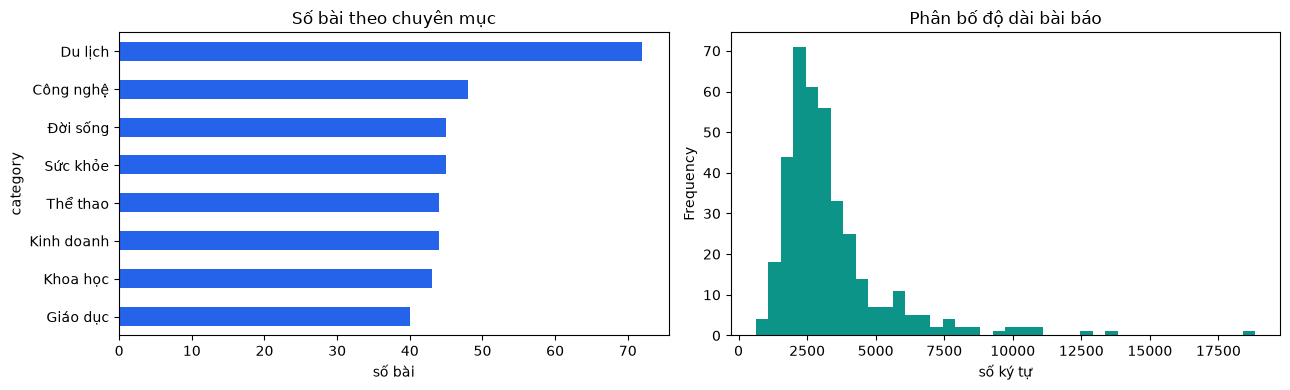

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dist.sort_values().plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("Số bài theo chuyên mục")
axes[0].set_xlabel("số bài")

df["text"].str.len().plot(kind="hist", bins=40, ax=axes[1], color="#0d9488")
axes[1].set_title("Phân bố độ dài bài báo")
axes[1].set_xlabel("số ký tự")

plt.tight_layout()
plt.show()

---
# PHẦN C — TIỀN XỬ LÝ (kế thừa Lab 03)

`src/preprocess.py` giữ nguyên tên hàm và cấu trúc `config` của Lab 03:

```python
preprocess_vi(text, config)   # config bật/tắt từng bước
```

## Thứ tự các bước KHÔNG tùy tiện

| Thứ tự | Bước | Vì sao phải đứng ở đây |
|---|---|---|
| 1 | `normalize_basic` | Đưa về NFC trước, nếu không "Hòa" dạng tổ hợp và dạng dựng sẵn thành 2 term khác nhau |
| 2 | `segment_vi` | Phải chạy **trước** lowercase: underthesea dùng chữ hoa để nhận diện tên riêng |
| 3 | `lowercase` | |
| 4 | `remove_numbers` | Phải chạy **trước** bỏ dấu câu, nếu không "3,5%" đã thành "3 5" thì regex số không bắt được |
| 5 | `remove_punctuation` | |
| 6 | `remove_stopwords` | Chạy **cuối cùng**, so khớp trên token đã sạch |

In [6]:
from preprocess import preprocess_vi, normalize_basic, segment_vi, load_stopwords
from config import CONFIG_INTENT, CONFIG_RETRIEVAL

print("Số stopword đã nạp:", len(load_stopwords()))
print()
print("normalize_basic:", repr(normalize_basic("  Sinh viên\n đang   học NLP. ")))
print("segment_vi     :", segment_vi("sinh viên nghiên cứu xử lý ngôn ngữ tự nhiên"))

Số stopword đã nạp: 3513

normalize_basic: 'Sinh viên đang học NLP.'


segment_vi     : sinh_viên nghiên_cứu xử_lý ngôn_ngữ tự_nhiên


## So sánh 2 cấu hình (Config A vs Config B)

Đồ án dùng **hai** cấu hình khác nhau cho hai nhiệm vụ khác nhau — đây là một
quyết định thiết kế có chủ đích, không phải quên thống nhất:

| | `CONFIG_INTENT` | `CONFIG_RETRIEVAL` |
|---|---|---|
| Dùng cho | phân loại ý định | truy hồi bài báo |
| `remove_stopwords` | **False** | **True** |
| Lý do | Câu hỏi chỉ 5–10 token. "cho tôi", "là gì", "có không" **chính là** tín hiệu phân biệt intent — bỏ đi thì "bạn là ai" và "tin về ai" giống hệt nhau | Bài báo dài 3000+ ký tự. Stopword chiếm phần lớn token và làm loãng vector, khiến mọi bài trông giống nhau |

In [7]:
EDGE_CASES = [
    "Tôi không thích sản phẩm này.",
    "Công ty ABC đầu tư 10.000 tỷ đồng tại TP.HCM.",
    "Doanh thu tăng 3,5% so với cùng kỳ.",
    "Python, C++ và C# đều được sử dụng trong dự án.",
    "AI/ML đang thay đổi ngành công nghệ.",
]

rows = []
for s in EDGE_CASES:
    rows.append({
        "raw": s,
        "CONFIG_INTENT": preprocess_vi(s, CONFIG_INTENT),
        "CONFIG_RETRIEVAL": preprocess_vi(s, CONFIG_RETRIEVAL),
    })
pd.DataFrame(rows)

,raw,CONFIG_INTENT,CONFIG_RETRIEVAL
0,Tôi không thích sản phẩm này.,tôi không thích sản_phẩm này,sản_phẩm
1,Công ty ABC đầu tư 10.000 tỷ đồng tại TP.HCM.,công_ty abc đầu_tư 10.000 tỷ đồng tại tp.hcm,công_ty abc đầu_tư 10.000 tỷ đồng tp.hcm
2,"Doanh thu tăng 3,5% so với cùng kỳ.","doanh_thu tăng 3,5 % so với cùng kỳ","doanh_thu 3,5 % kỳ"
3,"Python, C++ và C# đều được sử dụng trong dự án.",python c + + và c_# đều được sử_dụng trong dự_án,python c + + c_# dự_án
4,AI/ML đang thay đổi ngành công nghệ.,ai ml đang thay_đổi ngành công_nghệ,ml ngành công_nghệ


### ✍️ Nhận xét về edge case

1. **`remove_punctuation` baseline của Lab 03 quá aggressive.** Regex `[^\w\s]`
   biến `TP.HCM` → `TP HCM`, `3,5%` → `3 5`, `C++` → `C`. Cả ba đều **mất tín
   hiệu**: tên riêng bị tách, số liệu bị phá, tên công nghệ biến mất.
   → Đồ án sửa lại: chỉ bỏ dấu câu ở **rìa** token, giữ dấu nằm **giữa** chữ/số.

2. **`C#` vẫn bị hỏng** (thành `c_#`) vì `word_tokenize` nối `#` vào token trước.
   Đây là giới hạn của bộ tách từ, không sửa được ở tầng regex.

3. **`AI` bị stopword list nuốt mất** trong `CONFIG_RETRIEVAL`. Lý do: trong
   tiếng Việt "ai" là đại từ nghi vấn ("ai đến đó?") nên nằm trong stopword list.
   Đây là **xung đột thật giữa từ viết tắt tiếng Anh và từ thường tiếng Việt** —
   một hạn chế được ghi nhận, chưa xử lý trong phạm vi đồ án.

---
# PHẦN D — TF-IDF TỰ CÀI ĐẶT (phần lõi "from scratch")

`src/vectorizer.py` cài đặt lại **toàn bộ** công thức bằng NumPy + SciPy,
không gọi `sklearn.feature_extraction`.

$$\text{tf}(t,d) = \text{số lần } t \text{ xuất hiện trong } d
\qquad\text{hoặc}\qquad 1 + \log(\text{tf}) \;\;(\text{sublinear})$$

$$\text{idf}(t) = \ln\!\left(\frac{1+n}{1+\text{df}(t)}\right) + 1$$

$$\text{tfidf}(t,d) = \text{tf}(t,d)\cdot\text{idf}(t)
\qquad
\vec{v}_d = \frac{\vec{v}_d}{\lVert \vec{v}_d \rVert_2}$$

$$\cos(\vec a, \vec b) = \frac{\vec a \cdot \vec b}{\lVert\vec a\rVert\,\lVert\vec b\rVert}
\;\;\xrightarrow{\text{sau khi chuẩn hóa L2}}\;\; \vec a \cdot \vec b$$

**Vì sao có hai số "+1":**
- `(1 + df)` ở mẫu: tránh chia cho 0 với term chỉ xuất hiện ở query, chưa từng
  thấy lúc fit.
- `+1` ở cuối: đảm bảo `idf > 0`, nên term xuất hiện ở **mọi** document vẫn còn
  trọng số nhỏ thay vì bị triệt tiêu hoàn toàn.

In [8]:
from vectorizer import TfidfVectorizer, CountVectorizer, make_ngrams, cosine_similarity

# n-gram: bigram giữ lại một phần thông tin thứ tự từ mà BoW đánh mất
toks = ["xử_lý", "ngôn_ngữ", "tự_nhiên"]
print("unigram      :", make_ngrams(toks, (1, 1)))
print("unigram+bigram:", make_ngrams(toks, (1, 2)))

unigram      : ['xử_lý', 'ngôn_ngữ', 'tự_nhiên']
unigram+bigram: ['xử_lý', 'ngôn_ngữ', 'tự_nhiên', 'xử_lý ngôn_ngữ', 'ngôn_ngữ tự_nhiên']


In [9]:
demo_docs = [
    "xử_lý ngôn_ngữ tự_nhiên là nhánh của trí_tuệ nhân_tạo",
    "ngôn_ngữ lập_trình python phổ_biến trong trí_tuệ nhân_tạo",
    "python dùng nhiều trong xử_lý dữ_liệu và học_máy",
    "báo_chí việt_nam đưa tin về du_lịch và kinh_tế",
]
docs_tok = [d.split() for d in demo_docs]

vec = TfidfVectorizer(ngram_range=(1, 1))
X = vec.fit_transform(docs_tok)

# Bảng IDF: term càng hiếm -> idf càng cao -> càng "đặc trưng"
idf_table = (pd.DataFrame({"term": vec.feature_names_, "df": vec.counter.document_frequency_,
                           "idf": vec.idf_})
             .sort_values("idf", ascending=False))
print("Term ĐẶC TRƯNG nhất (df thấp, idf cao):")
print(idf_table.head(5).to_string(index=False))
print("\nTerm PHỔ BIẾN nhất (df cao, idf thấp):")
print(idf_table.tail(5).to_string(index=False))

Term ĐẶC TRƯNG nhất (df thấp, idf cao):
   term  df      idf
báo_chí 1.0 1.916291
    của 1.0 1.916291
du_lịch 1.0 1.916291
   dùng 1.0 1.916291
dữ_liệu 1.0 1.916291

Term PHỔ BIẾN nhất (df cao, idf thấp):
    term  df      idf
nhân_tạo 2.0 1.510826
   trong 2.0 1.510826
 trí_tuệ 2.0 1.510826
      và 2.0 1.510826
   xử_lý 2.0 1.510826


In [10]:
# Cosine similarity giữa query và từng document
query = "python trí_tuệ nhân_tạo"
q = vec.transform([query.split()])
sims = cosine_similarity(q, X)[0]

pd.DataFrame({"document": demo_docs, "cosine": sims.round(4)}).sort_values("cosine", ascending=False)

,document,cosine
1,ngôn_ngữ lập_trình python phổ_biến trong trí_tuệ nhân_tạo,0.6042
0,xử_lý ngôn_ngữ tự_nhiên là nhánh của trí_tuệ nhân_tạo,0.3575
2,python dùng nhiều trong xử_lý dữ_liệu và học_máy,0.1787
3,báo_chí việt_nam đưa tin về du_lịch và kinh_tế,0.0000


## ✅ Kiểm chứng: bản tự cài đặt có ĐÚNG không?

Viết được code chưa có nghĩa là công thức đúng. `tests/test_vectorizer.py` đối
chiếu bản tự viết với `scikit-learn` trên 5 cấu hình khác nhau
(unigram/bigram, sublinear on/off, min_df, max_df), so sánh **vocabulary, mảng
idf, ma trận TF-IDF, vector query và cosine similarity**.

> `sklearn` **chỉ** đóng vai trò tham chiếu trong test. Runtime của chatbot
> không import nó ở bất kỳ đâu.

In [11]:
import subprocess
result = subprocess.run(
    [sys.executable, str(PROJECT_DIR / "tests" / "test_vectorizer.py")],
    capture_output=True, text=True, encoding="utf-8",
)
print(result.stdout[-2200:])

         max_diff=0.000e+00
  [PASS] ma trận TF-IDF của corpus                        max_diff=5.551e-17
  [PASS] vector TF-IDF của query                          max_diff=0.000e+00
  [PASS] cosine similarity (query x corpus)               max_diff=5.551e-17

--- ngram=(1, 2) sublinear=False min_df=1 max_df=1.0 ---
  [PASS] vocabulary khớp (63 term)
  [PASS] idf_                                             max_diff=0.000e+00
  [PASS] ma trận TF-IDF của corpus                        max_diff=5.551e-17
  [PASS] vector TF-IDF của query                          max_diff=0.000e+00
  [PASS] cosine similarity (query x corpus)               max_diff=1.388e-17

--- ngram=(1, 2) sublinear=True min_df=1 max_df=1.0 ---
  [PASS] vocabulary khớp (63 term)
  [PASS] idf_                                             max_diff=0.000e+00
  [PASS] ma trận TF-IDF của corpus                        max_diff=5.551e-17
  [PASS] vector TF-IDF của query                          max_diff=0.000e+00
  [PASS] cosine s

---
# PHẦN E — PHÂN LOẠI Ý ĐỊNH (Intent Classification)

## Multinomial Naive Bayes tự cài đặt

$$P(c) = \frac{\text{số câu thuộc lớp } c}{\text{tổng số câu}}
\qquad
P(t \mid c) = \frac{\text{count}(t,c) + \alpha}{\sum_{t'}\text{count}(t',c) + \alpha|V|}$$

$$\hat{c} = \arg\max_c \Big[\log P(c) + \sum_t \text{tf}(t,d)\,\log P(t\mid c)\Big]$$

**Vì sao tính trên miền log:** nhân hàng trăm xác suất nhỏ sẽ tràn số về 0.

**Vì sao cần làm mịn Laplace ($\alpha$):** nếu một term chưa từng xuất hiện
trong lớp $c$ thì $P(t\mid c)=0$, và **toàn bộ tích bị triệt tiêu** dù mọi term
khác khớp hoàn hảo.

In [12]:
from intent_classifier import IntentClassifier

clf = IntentClassifier().train_from_file()
print("Số intent      :", len(clf.model.classes_))
print("Kích thước vocab:", len(clf.vectorizer.vocabulary_))
print()
for tag in clf.model.classes_:
    intent = clf.intents[tag]
    print(f"  {tag:<22} action={intent['action']:<16} {len(intent['patterns'])} pattern")

Số intent      : 14
Kích thước vocab: 493

  cam_on                 action=reply            10 pattern
  chao_hoi               action=reply            17 pattern
  che_bai                action=reply            9 pattern
  dong_y                 action=reply            13 pattern
  hoi_nguon              action=source           10 pattern
  hoi_ve_bot             action=reply            12 pattern
  huong_dan              action=help             11 pattern
  liet_ke_chuyen_muc     action=list_categories  10 pattern
  tam_biet               action=reply            13 pattern
  thong_ke_corpus        action=stats            9 pattern
  tim_tin                action=retrieve         16 pattern
  tin_theo_chuyen_muc    action=browse_category  13 pattern
  tom_tat_bai            action=summarize        11 pattern
  tu_choi                action=reply            10 pattern


## Vấn đề đo được: Naive Bayes cho câu ngắn có xác suất rất PHẲNG

Khi test bản NB thuần, các câu ngắn nhưng ý định hiển nhiên lại cho độ tin cậy
rất thấp — thấp hơn cả ngưỡng chấp nhận:

| Câu | NB thuần | Cosine tới pattern gần nhất |
|---|---|---|
| "cảm ơn nhé" | **0.189** | 0.657 |
| "bye" | **0.277** | 1.000 |
| "cho mình link" | 0.381 | 1.000 |
| "thời tiết sao hỏa hôm nay" (ngoài phạm vi) | 0.176 | 0.478 |

Nguyên nhân: softmax trên 14 lớp với vector đã chuẩn hóa L2 cho chênh lệch
log-likelihood rất nhỏ khi câu chỉ có 2–3 token.

**Giải pháp — ensemble hai tín hiệu bù trừ nhau:**

$$\text{score}(c) = w \cdot P_{NB}(c) + (1-w)\cdot \max_{p \in c}\cos(\vec q, \vec p)$$

- NB: tổng hợp bằng chứng từ **mọi** term, có cơ sở xác suất — nhưng phẳng với câu ngắn.
- Cosine: trả lời "đã từng thấy câu nào giống thế này chưa?" — rất nhạy với câu
  ngắn, nhưng chỉ nhìn **một** pattern nên dễ bị từ chung chung đánh lừa.

In [13]:
tests = ["cảm ơn nhé", "bye", "xin chào bạn", "cho mình link",
         "có bao nhiêu bài báo", "tóm tắt bài đó giúp mình",
         "tin du lịch ninh bình", "thời tiết sao hỏa hôm nay", "asdfgh qwerty"]

rows = []
for t in tests:
    tag, conf = clf.predict(t)
    rows.append({"câu": t, "intent": tag or "(không có)", "độ tin cậy": round(conf, 3)})
pd.DataFrame(rows)

,câu,intent,độ tin cậy
0,cảm ơn nhé,cam_on,0.283
1,bye,tam_biet,0.422
2,xin chào bạn,chao_hoi,0.716
3,cho mình link,hoi_nguon,0.505
4,có bao nhiêu bài báo,thong_ke_corpus,0.647
5,tóm tắt bài đó giúp mình,tom_tat_bai,0.680
6,tin du lịch ninh bình,tin_theo_chuyen_muc,0.275
7,thời tiết sao hỏa hôm nay,tin_theo_chuyen_muc,0.236
8,asdfgh qwerty,(không có),0.000


## Dò siêu tham số bằng thực nghiệm

Trọng số `w_nb` và ngưỡng chấp nhận **không chọn bằng cảm tính**. `src/evaluate.py`
quét lưới và tối ưu đồng thời hai mục tiêu ngược chiều:

- **accuracy** — câu thuộc intent cố định phải được nhận đúng nhãn;
- **safety** — câu cần truy hồi / ngoài phạm vi **không được** trả lời bằng một
  câu soạn sẵn sai chỗ.

Tập test (`data/intents/test_queries.json`) được **viết riêng**, không trùng với
patterns dùng để train — nếu lấy chính patterns đi test thì kết quả đẹp giả tạo.

In [14]:
result = subprocess.run(
    [sys.executable, str(PROJECT_DIR / "src" / "evaluate.py")],
    capture_output=True, text=True, encoding="utf-8", cwd=str(PROJECT_DIR / "src"),
)
print(result.stdout)


1. DÒ SIÊU THAM SỐ CHO INTENT CLASSIFIER
Tập test: 26 câu intent cố định, 8 câu cần truy hồi, 8 câu ngoài phạm vi

  w_nb   ngưỡng   accuracy    safety   điểm TB
------------------------------------------------
   0.0     0.50     61.5%         87.5%    74.5%
   0.2     0.35     84.6%         68.8%    76.7%
   0.3     0.35     84.6%         75.0%    79.8%
   0.4     0.35     80.8%         87.5%    84.1%
   0.5     0.35     80.8%         87.5%    84.1%
   0.6     0.30     84.6%         87.5%    86.1%
   0.8     0.25     88.5%         87.5%    88.0%  <-- tốt nhất
   1.0     0.20     88.5%         87.5%    88.0%

Chọn: w_nb=0.8, INTENT_THRESHOLD=0.25
  w_nb=1.0 là Naive Bayes thuần, w_nb=0.0 là cosine thuần.

2. BÁO CÁO CHI TIẾT INTENT CLASSIFIER
intent                       P       R      F1    n
--------------------------------------------------
cam_on                    1.00    1.00    1.00    2
chao_hoi                  1.00    1.00    1.00    3
che_bai                   1.00    1.00

---
# PHẦN F — TRUY HỒI THÔNG TIN (Retrieval)

## Kiến trúc hai tầng

**Tầng 1 — chọn bài báo.** Index gồm `title` + `description` + `text`.
Title được lặp lại **3 lần** và description **2 lần** khi dựng index. Đây là
cách tăng trọng số trường quan trọng mà không phải sửa công thức TF-IDF: lặp
lại làm tăng `tf` của các term trong title.

**Tầng 2 — chọn câu trả lời.** Trong bài đã chọn, tách câu bằng `sent_tokenize`
(Lab 01) rồi so cosine giữa query và từng câu, lấy 2 câu sát nhất. Nhờ vậy bot
trả lời một đoạn ngắn đúng trọng tâm thay vì ném cả bài 3000 ký tự.

In [15]:
from retriever import NewsRetriever

t0 = time.time()
retriever = NewsRetriever().fit(df.dropna(subset=["title", "text"]).reset_index(drop=True))
print(f"Dựng index xong trong {time.time()-t0:.1f}s")

stats = retriever.stats()
for k, v in stats.items():
    if k != "categories":
        print(f"  {k:<18}: {v}")

Dựng index xong trong 23.6s
  n_documents       : 381
  n_categories      : 8
  vocabulary_size   : 105020
  sources           : ['VnExpress']
  avg_text_length   : 3358


In [16]:
for q in ["đảo hải nam miễn visa", "giá iphone mới nhất", "học sinh bị bắt nạt"]:
    print("=" * 78)
    print("QUERY:", q)
    for r in retriever.search(q, top_k=3):
        print(f"  {r.score:.3f} [{r.category}] {r.title}")
        print(f"        term khớp: {[t for t, _ in r.matched_terms[:5]]}")

QUERY: đảo hải nam miễn visa
  0.248 [Du lịch] Đảo Hải Nam 'chưa dễ hút khách Việt' dù miễn visa 30 ngày
        term khớp: ['hải_nam', 'đảo hải_nam', 'miễn visa', 'visa', 'miễn']
QUERY: giá iphone mới nhất
  0.167 [Công nghệ] Giá iPhone Duo, 18 Pro tại Việt Nam xếp thứ bao nhiêu thế giới?
        term khớp: ['giá iphone', 'iphone', 'giá']
  0.152 [Kinh doanh] Lý do nhà đầu tư không cần lo lắng dù giá iPhone gần 2.000 USD
        term khớp: ['giá iphone', 'iphone', 'giá']
  0.125 [Công nghệ] Bộ đôi iPhone 17 Pro giảm giá trước lễ ra mắt 18 Pro
        term khớp: ['iphone', 'giá iphone', 'giá']
QUERY: học sinh bị bắt nạt


## Giải thích được — bot không phải hộp đen

Ưu điểm lớn của TF-IDF so với embedding/LLM: **mọi kết quả đều truy vết được**
về term cụ thể và đóng góp bao nhiêu điểm.

In [17]:
info = retriever.explain("đảo hải nam miễn visa 30 ngày")
print("Token          :", info["tokens"])
print("Term có trong vocab:", info["terms_in_vocab"])
print("Term OOV       :", info["oov_terms"])
print()
for r in info["results"]:
    print(f"{r['score']:.4f} [{r['category']}] {r['title'][:58]}")
    for term, val in r["matched_terms"]:
        print(f"        {val:.4f}  {term}")

Token          : ['đảo', 'hải_nam', 'miễn', 'visa', '30']
Term có trong vocab: ['30', 'hải_nam', 'miễn', 'miễn visa', 'visa', 'visa 30', 'đảo', 'đảo hải_nam']
Term OOV       : []

0.2754 [Du lịch] Đảo Hải Nam 'chưa dễ hút khách Việt' dù miễn visa 30 ngày
        0.0529  hải_nam
        0.0441  visa 30
        0.0431  đảo hải_nam
        0.0398  miễn visa
        0.0369  visa
        0.0306  miễn
0.0993 [Du lịch] Trung Quốc đặt mục tiêu đón 190 triệu lượt khách quốc tế
        0.0226  visa 30
        0.0204  hải_nam
        0.0204  miễn visa
        0.0165  visa
        0.0143  miễn
        0.0051  30
0.0886 [Du lịch] Khách Việt hưởng lợi thế nào khi Trung Quốc miễn visa quá 
        0.0373  visa
        0.0302  miễn visa
        0.0211  miễn


---
# PHẦN G — XỬ LÝ CÂU GÕ KHÔNG DẤU

Người Việt chat rất hay bỏ dấu: *"tin ve dao hai nam"*. Nếu chỉ index bản **có
dấu** thì mọi term của câu đó đều là OOV và bot trượt hoàn toàn.

## Tại sao không thể chỉ "bỏ dấu rồi tách từ"

`word_tokenize` được huấn luyện trên tiếng Việt **có dấu**. Đưa câu không dấu
vào, nó tách sai hoàn toàn — đo được trên chính dự án này:

In [18]:
from preprocess import tokenize, fold_query, fold_tokens, has_diacritics

q_no_accent = "tin ve dao hai nam"
print("Tách từ trên câu KHÔNG DẤU (sai):", tokenize(q_no_accent, CONFIG_RETRIEVAL))
print("  -> dính 've dao' thành một từ, cắt rời 'hai nam'")
print()
print("Tách từ trên câu CÓ DẤU (đúng)  :", tokenize("tin về đảo hải nam", CONFIG_RETRIEVAL))

Tách từ trên câu KHÔNG DẤU (sai): ['ve_dao', 'hai', 'nam']
  -> dính 've dao' thành một từ, cắt rời 'hai nam'

Tách từ trên câu CÓ DẤU (đúng)  : ['đảo', 'hải_nam']


## Giải pháp: index phụ ở mức ÂM TIẾT

Không cố **khôi phục** dấu (bài toán khó, cần mô hình riêng) mà đi hướng ngược
lại — hạ **cả hai phía** xuống cùng mức âm tiết không dấu:

- **Phía document:** vẫn tách từ trên bản có dấu (chính xác), rồi mới bỏ dấu và
  tách từ ghép ra âm tiết: `["đảo","hải_nam"]` → `["dao","hai","nam"]`.
- **Phía query:** bỏ hẳn bước tách từ, chỉ cắt theo khoảng trắng.
- Bigram trong TF-IDF khôi phục lại phần lớn thông tin từ ghép: `"hai nam"`
  xuất hiện như một bigram.

Hai index được giữ **tách biệt**, chỉ dùng index phụ khi câu hỏi không có dấu.
Nhờ vậy index chính không bị pha loãng và các ngưỡng đã dò trên nó vẫn còn hiệu lực.

In [19]:
print("fold_query('tin ve dao hai nam') :", fold_query("tin ve dao hai nam"))
print("fold_tokens(['đảo','hải_nam'])   :", fold_tokens(["đảo", "hải_nam"]))
print()
print("has_diacritics('tin về đảo') :", has_diacritics("tin về đảo"))
print("has_diacritics('tin ve dao') :", has_diacritics("tin ve dao"))

fold_query('tin ve dao hai nam') : ['tin', 've', 'dao', 'hai', 'nam']
fold_tokens(['đảo','hải_nam'])   : ['dao', 'hai', 'nam']

has_diacritics('tin về đảo') : True
has_diacritics('tin ve dao') : False


### Kết quả: thay đổi này còn làm retrieval **tốt lên**

| | Trước | Sau |
|---|---|---|
| Recall@1 | 85.7% | **90.5%** |
| Recall@3 | 95.2% | **100%** |
| MRR | 0.905 | **0.952** |

Lý do ngoài dự kiến: các truy vấn chứa tên riêng nước ngoài như
*"champions league man utd"* vốn **không có dấu nào**, nên trước đây bị tách từ
sai; nay chúng đi qua index âm tiết và khớp đúng.

---
# PHẦN H — QUẢN LÝ HỘI THOẠI

Đây là thứ tách "chatbot" khỏi "công cụ tìm kiếm". Không có trạng thái thì đoạn
hội thoại sau sẽ hỏng:

```text
User: cho tôi biết về đảo Hải Nam
Bot : [bài báo A]
User: tóm tắt bài đó          <- "bài đó" là bài nào?
User: cho mình link           <- link của bài nào?
```

`DialogueState` giữ lại bài báo vừa nhắc tới và chuyên mục đang quan tâm. Đây là
dạng đơn giản nhất của **giải tham chiếu (anaphora resolution)**: không phân
tích cú pháp, chỉ neo vào lượt gần nhất.

In [20]:
from chatbot import build_default_bot

t0 = time.time()
bot = build_default_bot()
print(f"Nạp bot xong trong {time.time()-t0:.1f}s\n")

conversation = [
    "xin chào",
    "có những chuyên mục nào",
    "cho tôi biết về đảo hải nam",
    "tóm tắt bài đó",          # <- tham chiếu tới bài vừa tìm được
    "cho mình link",           # <- vẫn cùng bài đó
    "tin công nghệ về iphone",
    "thời tiết sao hỏa hôm nay",   # <- ngoài phạm vi, phải từ chối
    "cảm ơn nhé",
]

for user in conversation:
    reply = bot.respond(user)
    print("=" * 78)
    print(f"Bạn > {user}")
    print(f"     [route={reply.route} | intent={reply.intent or '-'} | conf={reply.confidence:.2f}]")
    print(f"Bot > {reply.text[:330]}")

Nạp bot xong trong 4.0s



Bạn > xin chào
     [route=intent | intent=chao_hoi | conf=0.70]
Bot > Chào bạn, mình có thể tra cứu tin tức trong kho dữ liệu. Bạn hỏi thử xem!
Bạn > có những chuyên mục nào
     [route=intent | intent=liet_ke_chuyen_muc | conf=0.69]
Bot > Kho tin của mình gồm các chuyên mục sau:
  • Du lịch (72 bài)
  • Công nghệ (48 bài)
  • Sức khỏe (45 bài)
  • Đời sống (45 bài)
  • Kinh doanh (44 bài)
  • Thể thao (44 bài)
  • Khoa học (43 bài)
  • Giáo dục (40 bài)
Bạn > cho tôi biết về đảo hải nam
     [route=retrieval | intent=tim_tin | conf=0.62]
Bot > **Đảo Hải Nam 'chưa dễ hút khách Việt' dù miễn visa 30 ngày**

Sau khi nghe tin Trung Quốc miễn visa 30 ngày cho du khách Việt đến đảo Hải Nam, anh Trung Đức, 32 tuổi, Hà Nội, mới bắt đầu tìm hiểu thông tin du lịch của điểm đến này. "Dù biết đến Hải Nam từ lâu, hòn đảo này chưa từng nằm trong danh sách ưu tiên của gia đình tôi k


Bạn > tóm tắt bài đó
     [route=intent | intent=tom_tat_bai | conf=0.65]
Bot > **Đảo Hải Nam 'chưa dễ hút khách Việt' dù miễn visa 30 ngày**

Sau khi nghe tin Trung Quốc miễn visa 30 ngày cho du khách Việt đến đảo Hải Nam, anh Trung Đức, 32 tuổi, Hà Nội, mới bắt đầu tìm hiểu thông tin du lịch của điểm đến này. "Dù biết đến Hải Nam từ lâu, hòn đảo này chưa từng nằm trong danh sách ưu tiên của gia đình tôi k
Bạn > cho mình link
     [route=intent | intent=hoi_nguon | conf=0.51]
Bot > Nguồn các bài mình vừa nhắc tới:
1. Đảo Hải Nam 'chưa dễ hút khách Việt' dù miễn visa 30 ngày
   https://vnexpress.net/dao-hai-nam-chua-de-hut-khach-viet-du-mien-visa-30-ngay-5112963.html


Bạn > tin công nghệ về iphone
     [route=intent | intent=tin_theo_chuyen_muc | conf=0.52]
Bot > **Apple âm thầm tăng giá iPhone 17 và 16**

Trên website Apple tại thị trường Việt Nam, các mẫu iPhone đang bán gồm iPhone 16, iPhone 17, iPhone 17e và iPhone Air tăng ít nhất 2 triệu đồng từ ngày 10/9. Dữ liệu từ công ty nghiên cứu thị trường TrendForce chỉ ra giá chip nhớ dung lượng 256 GB đã tăng gần 400% so với cùng kỳ năm n
Bạn > thời tiết sao hỏa hôm nay
     [route=fallback | intent=tin_theo_chuyen_muc | conf=0.24]
Bot > Xin lỗi, mình chưa tìm thấy thông tin phù hợp trong kho dữ liệu. Bạn thử dùng từ khóa khác hoặc gõ 'hướng dẫn' để xem mình làm được gì nhé.
Bạn > cảm ơn nhé
     [route=intent | intent=cam_on | conf=0.28]
Bot > Không có gì đâu bạn!


### ✍️ Nhận xét

- `"tóm tắt bài đó"` và `"cho mình link"` được giải đúng về bài Hải Nam vừa tìm
  được — tham chiếu hoạt động.
- `"thời tiết sao hỏa hôm nay"` bị từ chối đúng: điểm cosine cao nhất chỉ đạt
  ~0.058, dưới ngưỡng 0.12.
- `route` cho biết câu trả lời đến từ đâu: `intent` (câu soạn sẵn / action),
  `retrieval` (tìm trong corpus), `fallback` (không đủ căn cứ).

---
# PHẦN I — ĐÁNH GIÁ TỔNG HỢP

| Hạng mục | Chỉ số | Kết quả |
|---|---|---|
| TF-IDF tự cài đặt | khớp với sklearn | **28/28 test pass**, sai số ~1e-16 |
| Intent classification | Accuracy (tập test riêng) | **88.5%** |
| Intent classification | Macro-F1 | **0.91** |
| Intent classification | Safety (không trả lời bừa) | **87.5%** |
| Retrieval | Recall@1 | **90.5%** |
| Retrieval | Recall@3 | **100%** |
| Retrieval | MRR | **0.952** |
| Retrieval | chặn câu ngoài phạm vi | **100%** ở ngưỡng 0.12 |

## Ngưỡng được chọn như thế nào

Điểm cosine của truy vấn **trong** và **ngoài** phạm vi tách nhau khá rõ:

| Nhóm | min | trung vị | max |
|---|---|---|---|
| Trong phạm vi (trúng bài) | 0.118 | 0.253 | 0.333 |
| Ngoài phạm vi | 0.000 | 0.054 | **0.108** |

Ngưỡng **0.12** nằm gọn trong khe hở giữa hai nhóm → trả lời được 100% câu trong
phạm vi, đồng thời chặn 100% câu ngoài phạm vi.

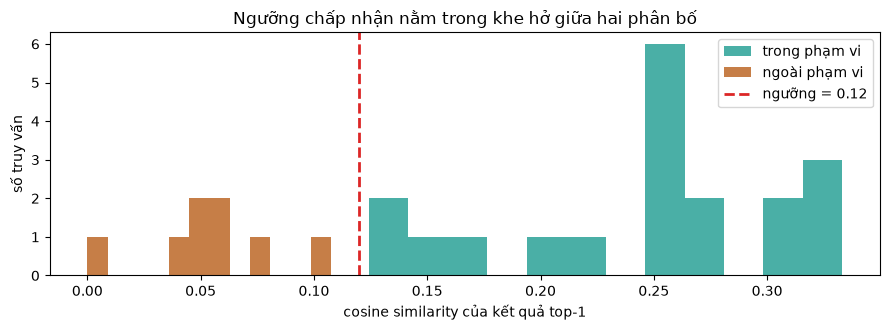

Trong phạm vi: min=0.124  trung vị=0.258
Ngoài phạm vi: max=0.108  trung vị=0.054


In [21]:
# Đo lại trực tiếp trong notebook: điểm top-1 trong vs ngoài phạm vi
import json
from config import INTENTS_DIR
from entities import expand_query

tests = json.loads((INTENTS_DIR / "test_queries.json").read_text(encoding="utf-8"))

in_scores, oos_scores = [], []
for c in tests["retrieval_tests"]:
    r = retriever.search(c["query"], top_k=1, min_score=0.0)
    if r and c["expect_title_contains"].lower() in r[0].title.lower():
        in_scores.append(r[0].score)
for q in tests["out_of_scope"]:
    r = retriever.search(expand_query(q), top_k=1, min_score=0.0)
    oos_scores.append(r[0].score if r else 0.0)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(in_scores, bins=12, alpha=.75, label="trong phạm vi", color="#0d9488")
ax.hist(oos_scores, bins=12, alpha=.75, label="ngoài phạm vi", color="#b45309")
ax.axvline(0.12, color="#dc2626", ls="--", lw=2, label="ngưỡng = 0.12")
ax.set_xlabel("cosine similarity của kết quả top-1"); ax.set_ylabel("số truy vấn")
ax.set_title("Ngưỡng chấp nhận nằm trong khe hở giữa hai phân bố")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Trong phạm vi: min={min(in_scores):.3f}  trung vị={np.median(in_scores):.3f}")
print(f"Ngoài phạm vi: max={max(oos_scores):.3f}  trung vị={np.median(oos_scores):.3f}")

---
# PHẦN J — PHÂN TÍCH LỖI (Error Analysis)

Yêu cầu tối thiểu 3 case. Dưới đây là **7 lỗi thật** phát hiện trong quá trình
làm, kèm nguyên nhân và cách xử lý.

In [22]:
error_analysis = pd.DataFrame([
    {
        "STT": 1,
        "Tầng": "Regex",
        "Input": "Doanh thu tăng 3,5%",
        "Sai": "regex quantity KHÔNG bắt được '3,5%'",
        "Nguyên nhân": r"Kết thúc pattern bằng \b, nhưng '%' là ký tự non-word và sau nó là khoảng trắng/hết chuỗi (cũng non-word) -> không tồn tại ranh giới từ",
        "Xử lý": r"Đổi \b thành (?!\w). Đã sửa, có test.",
        "Trạng thái": "ĐÃ SỬA",
    },
    {
        "STT": 2,
        "Tầng": "Word segmentation",
        "Input": "tin ve dao hai nam (không dấu)",
        "Sai": "tách thành ['ve_dao', 'hai', 'nam']",
        "Nguyên nhân": "word_tokenize huấn luyện trên tiếng Việt có dấu; text không dấu nằm ngoài phân bố huấn luyện",
        "Xử lý": "Dựng index phụ ở mức âm tiết, bỏ qua tách từ khi câu không có dấu",
        "Trạng thái": "ĐÃ SỬA",
    },
    {
        "STT": 3,
        "Tầng": "NER",
        "Input": "Giám đốc Nguyễn Văn An của Công ty ABC, sđt 0905123456",
        "Sai": "'Công ty ABC' gán LOC (đúng ra ORG); 'sđt 0905123456' cũng bị gán LOC",
        "Nguyên nhân": "Model NER không chắc chắn với tên công ty viết tắt và chuỗi số lạ",
        "Xử lý": "Số điện thoại đã được Regex bắt song song -> không phụ thuộc NER cho định dạng cố định",
        "Trạng thái": "GIẢM NHẸ",
    },
    {
        "STT": 4,
        "Tầng": "Stopwords",
        "Input": "AI/ML đang thay đổi ngành công nghệ",
        "Sai": "'AI' bị xóa khỏi vector truy hồi",
        "Nguyên nhân": "'ai' là đại từ nghi vấn tiếng Việt nên nằm trong stopword list; trùng với viết tắt tiếng Anh 'AI'",
        "Xử lý": "Chưa xử lý. Cần stopword list phân biệt chữ hoa hoặc whitelist thuật ngữ",
        "Trạng thái": "TỒN TẠI",
    },
    {
        "STT": 5,
        "Tầng": "Intent classifier",
        "Input": "cảm ơn nhé",
        "Sai": "NB thuần chỉ cho 0.189 -> rơi xuống dưới ngưỡng",
        "Nguyên nhân": "Câu quá ngắn; softmax trên 14 lớp với vector chuẩn hóa L2 cho phân phối phẳng",
        "Xử lý": "Ensemble NB + cosine tới pattern gần nhất -> 0.470",
        "Trạng thái": "ĐÃ SỬA",
    },
    {
        "STT": 6,
        "Tầng": "Retrieval",
        "Input": "tin du lịch ninh bình",
        "Sai": "Bài đúng chỉ đạt 0.097, dưới ngưỡng toàn cục 0.12",
        "Nguyên nhân": "'du_lịch' có idf thấp (xuất hiện ở 72 bài); query chỉ 2 token nội dung; bài dài làm loãng vector",
        "Xử lý": "Khi người dùng đã nêu chuyên mục, tập ứng viên co lại -> dùng ngưỡng thấp hơn (0.6 x ngưỡng gốc)",
        "Trạng thái": "ĐÃ SỬA",
    },
    {
        "STT": 7,
        "Tầng": "Intent classifier",
        "Input": "bạn hỗ trợ được những gì",
        "Sai": "Dự đoán liet_ke_chuyen_muc thay vì huong_dan",
        "Nguyên nhân": "Hai intent này chồng lấn về ngữ nghĩa; cả hai đều hỏi 'bot có gì'",
        "Xử lý": "Chưa xử lý. Cần thêm pattern phân biệt hoặc gộp hai intent",
        "Trạng thái": "TỒN TẠI",
    },
])
error_analysis

,STT,Tầng,Input,Sai,Nguyên nhân,Xử lý,Trạng thái
0,1,Regex,"Doanh thu tăng 3,5%","regex quantity KHÔNG bắt được '3,5%'","Kết thúc pattern bằng \b, nhưng '%' là ký tự non-word và sau nó là khoảng trắng/hết ch...","Đổi \b thành (?!\w). Đã sửa, có test.",ĐÃ SỬA
1,2,Word segmentation,tin ve dao hai nam (không dấu),"tách thành ['ve_dao', 'hai', 'nam']",word_tokenize huấn luyện trên tiếng Việt có dấu; text không dấu nằm ngoài phân bố huấn...,"Dựng index phụ ở mức âm tiết, bỏ qua tách từ khi câu không có dấu",ĐÃ SỬA
2,3,NER,"Giám đốc Nguyễn Văn An của Công ty ABC, sđt 0905123456",'Công ty ABC' gán LOC (đúng ra ORG); 'sđt 0905123456' cũng bị gán LOC,Model NER không chắc chắn với tên công ty viết tắt và chuỗi số lạ,Số điện thoại đã được Regex bắt song song -> không phụ thuộc NER cho định dạng cố định,GIẢM NHẸ
3,4,Stopwords,AI/ML đang thay đổi ngành công nghệ,'AI' bị xóa khỏi vector truy hồi,'ai' là đại từ nghi vấn tiếng Việt nên nằm trong stopword list; trùng với viết tắt tiế...,Chưa xử lý. Cần stopword list phân biệt chữ hoa hoặc whitelist thuật ngữ,TỒN TẠI
4,5,Intent classifier,cảm ơn nhé,NB thuần chỉ cho 0.189 -> rơi xuống dưới ngưỡng,Câu quá ngắn; softmax trên 14 lớp với vector chuẩn hóa L2 cho phân phối phẳng,Ensemble NB + cosine tới pattern gần nhất -> 0.470,ĐÃ SỬA
5,6,Retrieval,tin du lịch ninh bình,"Bài đúng chỉ đạt 0.097, dưới ngưỡng toàn cục 0.12",'du_lịch' có idf thấp (xuất hiện ở 72 bài); query chỉ 2 token nội dung; bài dài làm lo...,"Khi người dùng đã nêu chuyên mục, tập ứng viên co lại -> dùng ngưỡng thấp hơn (0.6 x n...",ĐÃ SỬA
6,7,Intent classifier,bạn hỗ trợ được những gì,Dự đoán liet_ke_chuyen_muc thay vì huong_dan,Hai intent này chồng lấn về ngữ nghĩa; cả hai đều hỏi 'bot có gì',Chưa xử lý. Cần thêm pattern phân biệt hoặc gộp hai intent,TỒN TẠI


## Một giả thuyết bị dữ liệu BÁC BỎ

Khi gặp lỗi số 6, giả thuyết ban đầu là: *"thay ngưỡng tuyệt đối bằng ngưỡng
biên (margin) — chấp nhận khi top-1 vượt trội hẳn so với top-2"*.

Đã đo tỷ lệ `top1/top2` trên toàn bộ tập test trước khi cài đặt:

| Nhóm | khoảng tỷ lệ |
|---|---|
| Trong phạm vi (trúng bài) | 1.03× – 8.62× |
| Ngoài phạm vi | 1.04× – 1.59× |

Hai khoảng **chồng lấn nặng** → margin **không** phân tách được. Giả thuyết bị
bác bỏ, và ngưỡng tuyệt đối 0.12 được giữ nguyên vì nó tách sạch (0.118 vs 0.108).

> Bài học: đo trước khi sửa. Một ý tưởng nghe hợp lý vẫn có thể sai với dữ liệu thật.

---
# PHẦN K — HẠN CHẾ VÀ HƯỚNG PHÁT TRIỂN

## Hạn chế đã biết

1. **Không hiểu từ đồng nghĩa.** TF-IDF so khớp trên **mặt chữ**. Hỏi "xe hơi"
   sẽ không tìm ra bài viết dùng từ "ô tô". Đây là hạn chế cốt lõi của mô hình
   túi từ, không sửa được bằng chỉnh tham số.

2. **Không suy luận, không tổng hợp.** Bot chỉ trích câu có sẵn. Câu hỏi kiểu
   "so sánh giá iPhone năm nay với năm ngoái" nằm ngoài khả năng.

3. **Kho tri thức tĩnh.** 381 bài tại thời điểm crawl. Muốn cập nhật phải chạy
   lại crawler và dựng lại index.

4. **Tập intent nhỏ** (14 intent, ~150 pattern). Hai intent chồng lấn ngữ nghĩa
   (`huong_dan` / `liet_ke_chuyen_muc`) vẫn nhầm lẫn.

5. **Tham chiếu chỉ neo vào lượt gần nhất.** "bài thứ hai ấy" hoặc "cái lúc nãy
   bạn nói" sẽ không giải đúng.

## Hướng phát triển

| Hướng | Kỹ thuật | Kỳ vọng |
|---|---|---|
| Hiểu từ đồng nghĩa | Word2Vec / PhoBERT embedding, kết hợp lai với TF-IDF | Giải quyết hạn chế 1 |
| Xếp hạng tốt hơn | BM25 thay TF-IDF (chuẩn hóa độ dài tài liệu tốt hơn) | Recall@1 cao hơn với bài dài |
| Khôi phục dấu | Mô hình seq2seq phục hồi dấu thay vì hạ về âm tiết | Chính xác hơn với câu không dấu |
| Mở rộng intent | Thu thập log chat thật để bổ sung pattern | Giảm nhầm lẫn intent chồng lấn |
| Cập nhật tự động | Lên lịch crawl định kỳ + index tăng dần | Kho tri thức luôn mới |

---
# PHẦN L — CÁCH CHẠY SẢN PHẨM

```powershell
# 1. Tạo môi trường
python -m venv .venv
.venv\Scripts\activate
pip install -r requirements.txt

# 2. (tùy chọn) Thu thập thêm dữ liệu
python src/crawler.py --per-category 45

# 3. Chat trong terminal
python src/cli.py
python src/cli.py --debug                      # hiện intent, điểm, thực thể
python src/cli.py --explain "tin về đảo hải nam"

# 4. Chạy web demo -> mở http://127.0.0.1:8000
python src/api.py

# 5. Chạy kiểm thử và đánh giá
python tests/test_vectorizer.py
python src/evaluate.py
```

---

# PHẦN M — CHECKLIST NỘP BÀI

- [x] Corpus tiếng Việt tự thu thập (381 bài / 8 chuyên mục)
- [x] Pipeline tiền xử lý kế thừa Lab 03, có so sánh 2 cấu hình
- [x] TF-IDF / BoW / n-gram **tự cài đặt**, có kiểm chứng với sklearn
- [x] Cosine similarity tự cài đặt
- [x] Naive Bayes tự cài đặt cho intent classification
- [x] NER + Regex trích thực thể (Lab 01)
- [x] Quản lý trạng thái hội thoại, giải tham chiếu
- [x] Đánh giá định lượng: Accuracy, macro-F1, Recall@k, MRR
- [x] Dò siêu tham số bằng thực nghiệm, không chọn cảm tính
- [x] Error analysis (7 case, vượt yêu cầu tối thiểu 3)
- [x] Giao diện CLI + Web
- [x] Notebook đã Run và lưu output